In [ ]:
!pip install ultralytics
!mkdir datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.9 MB/s eta 0:00:00


In [ ]:
import zipfile
import gdown

url_zip = "https://drive.google.com/file/d/1w9B8BedsIWRayFuj3H3JsYPUT8fpBgAL/view?usp=sharing"
output_dir = "/content/datasets/"

gdown.download(url_zip, output_dir, quiet=False, fuzzy=True)


zip_object = zipfile.ZipFile(file='./datasets/Objetos na Esteira.v12i.yolov8.zip', mode='r')
zip_object.extractall('./datasets/')
zip_object.close()

Downloading...
From (original): https://drive.google.com/uc?id=1vtBGuyyeSzc93E8lmJXNkfVr7qE-Ywou
From (redirected): https://drive.google.com/uc?id=1vtBGuyyeSzc93E8lmJXNkfVr7qE-Ywou&confirm=t&uuid=f1966b5c-7bf5-4e92-8296-d71d45e4751b
To: /content/datasets/Objetos na Esteira.v12i.yolov8.zip
100%|██████████| 118M/118M [00:04<00:00, 27.4MB/s]


In [ ]:
import ultralytics
ultralytics.checks()

from IPython.display import display, Image
from ultralytics import YOLO

Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.8/112.6 GB disk)


In [ ]:
# Versões disponíveis: n, s, m, l, x
model=YOLO("yolo11s.pt")
batch= 64

# Exemplos de Data augmentation
degrees=0.0
translate=0.0
scale=0.0
shear=0.0
perspective=0.000
flipud=0.0
fliplr=0.0
bgr=0
mosaic=0.0
mixup=0
copy_paste=0.0
erasing=0
crop_fraction=0

result = model.train(data='datasets/data.yaml',
                     epochs=150 ,
                     imgsz=640 ,
                     plots=True,
                     batch=batch,
                     degrees=degrees,
                     translate=translate,
                     scale=scale,
                     shear=shear,
                     perspective=perspective,
                     flipud=flipud,
                     fliplr=fliplr,
                     bgr=bgr,
                     mosaic=mosaic,
                     mixup=mixup,
                     copy_paste=copy_paste,
                     erasing=erasing,
                     crop_fraction=crop_fraction)

WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [ ]:
# Carrega o seu melhor modelo, que foi escolhido usando o conjunto de VALIDAÇÃO
model = YOLO('runs/detect/train3/weights/best.pt')

# Executa a avaliação final no conjunto de TESTE
metrics = model.val(
    data='datasets/data.yaml',
    split='test'
)

print("RESULTADO FINAL DO MODELO:")
print(f"mAP50-95 no conjunto de teste: {metrics.box.map:.4f}")

Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,416,670 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 22.1±6.8 MB/s, size: 53.9 KB)
val: Scanning /content/datasets/test/labels.cache... 221 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 221/221 446.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 3.1it/s 4.5s
                   all        221        221      0.996      0.999      0.995      0.956
           base_circle         24         24      0.992          1      0.995      0.995
          conical_ring         16         16          1          1      0.995      0.984
                cuboid         23         23      0.992          1      0.995      0.969
      cuboid_with_hole         23         23      0.992          1      0.995       0.94
              cylinder         20         20    

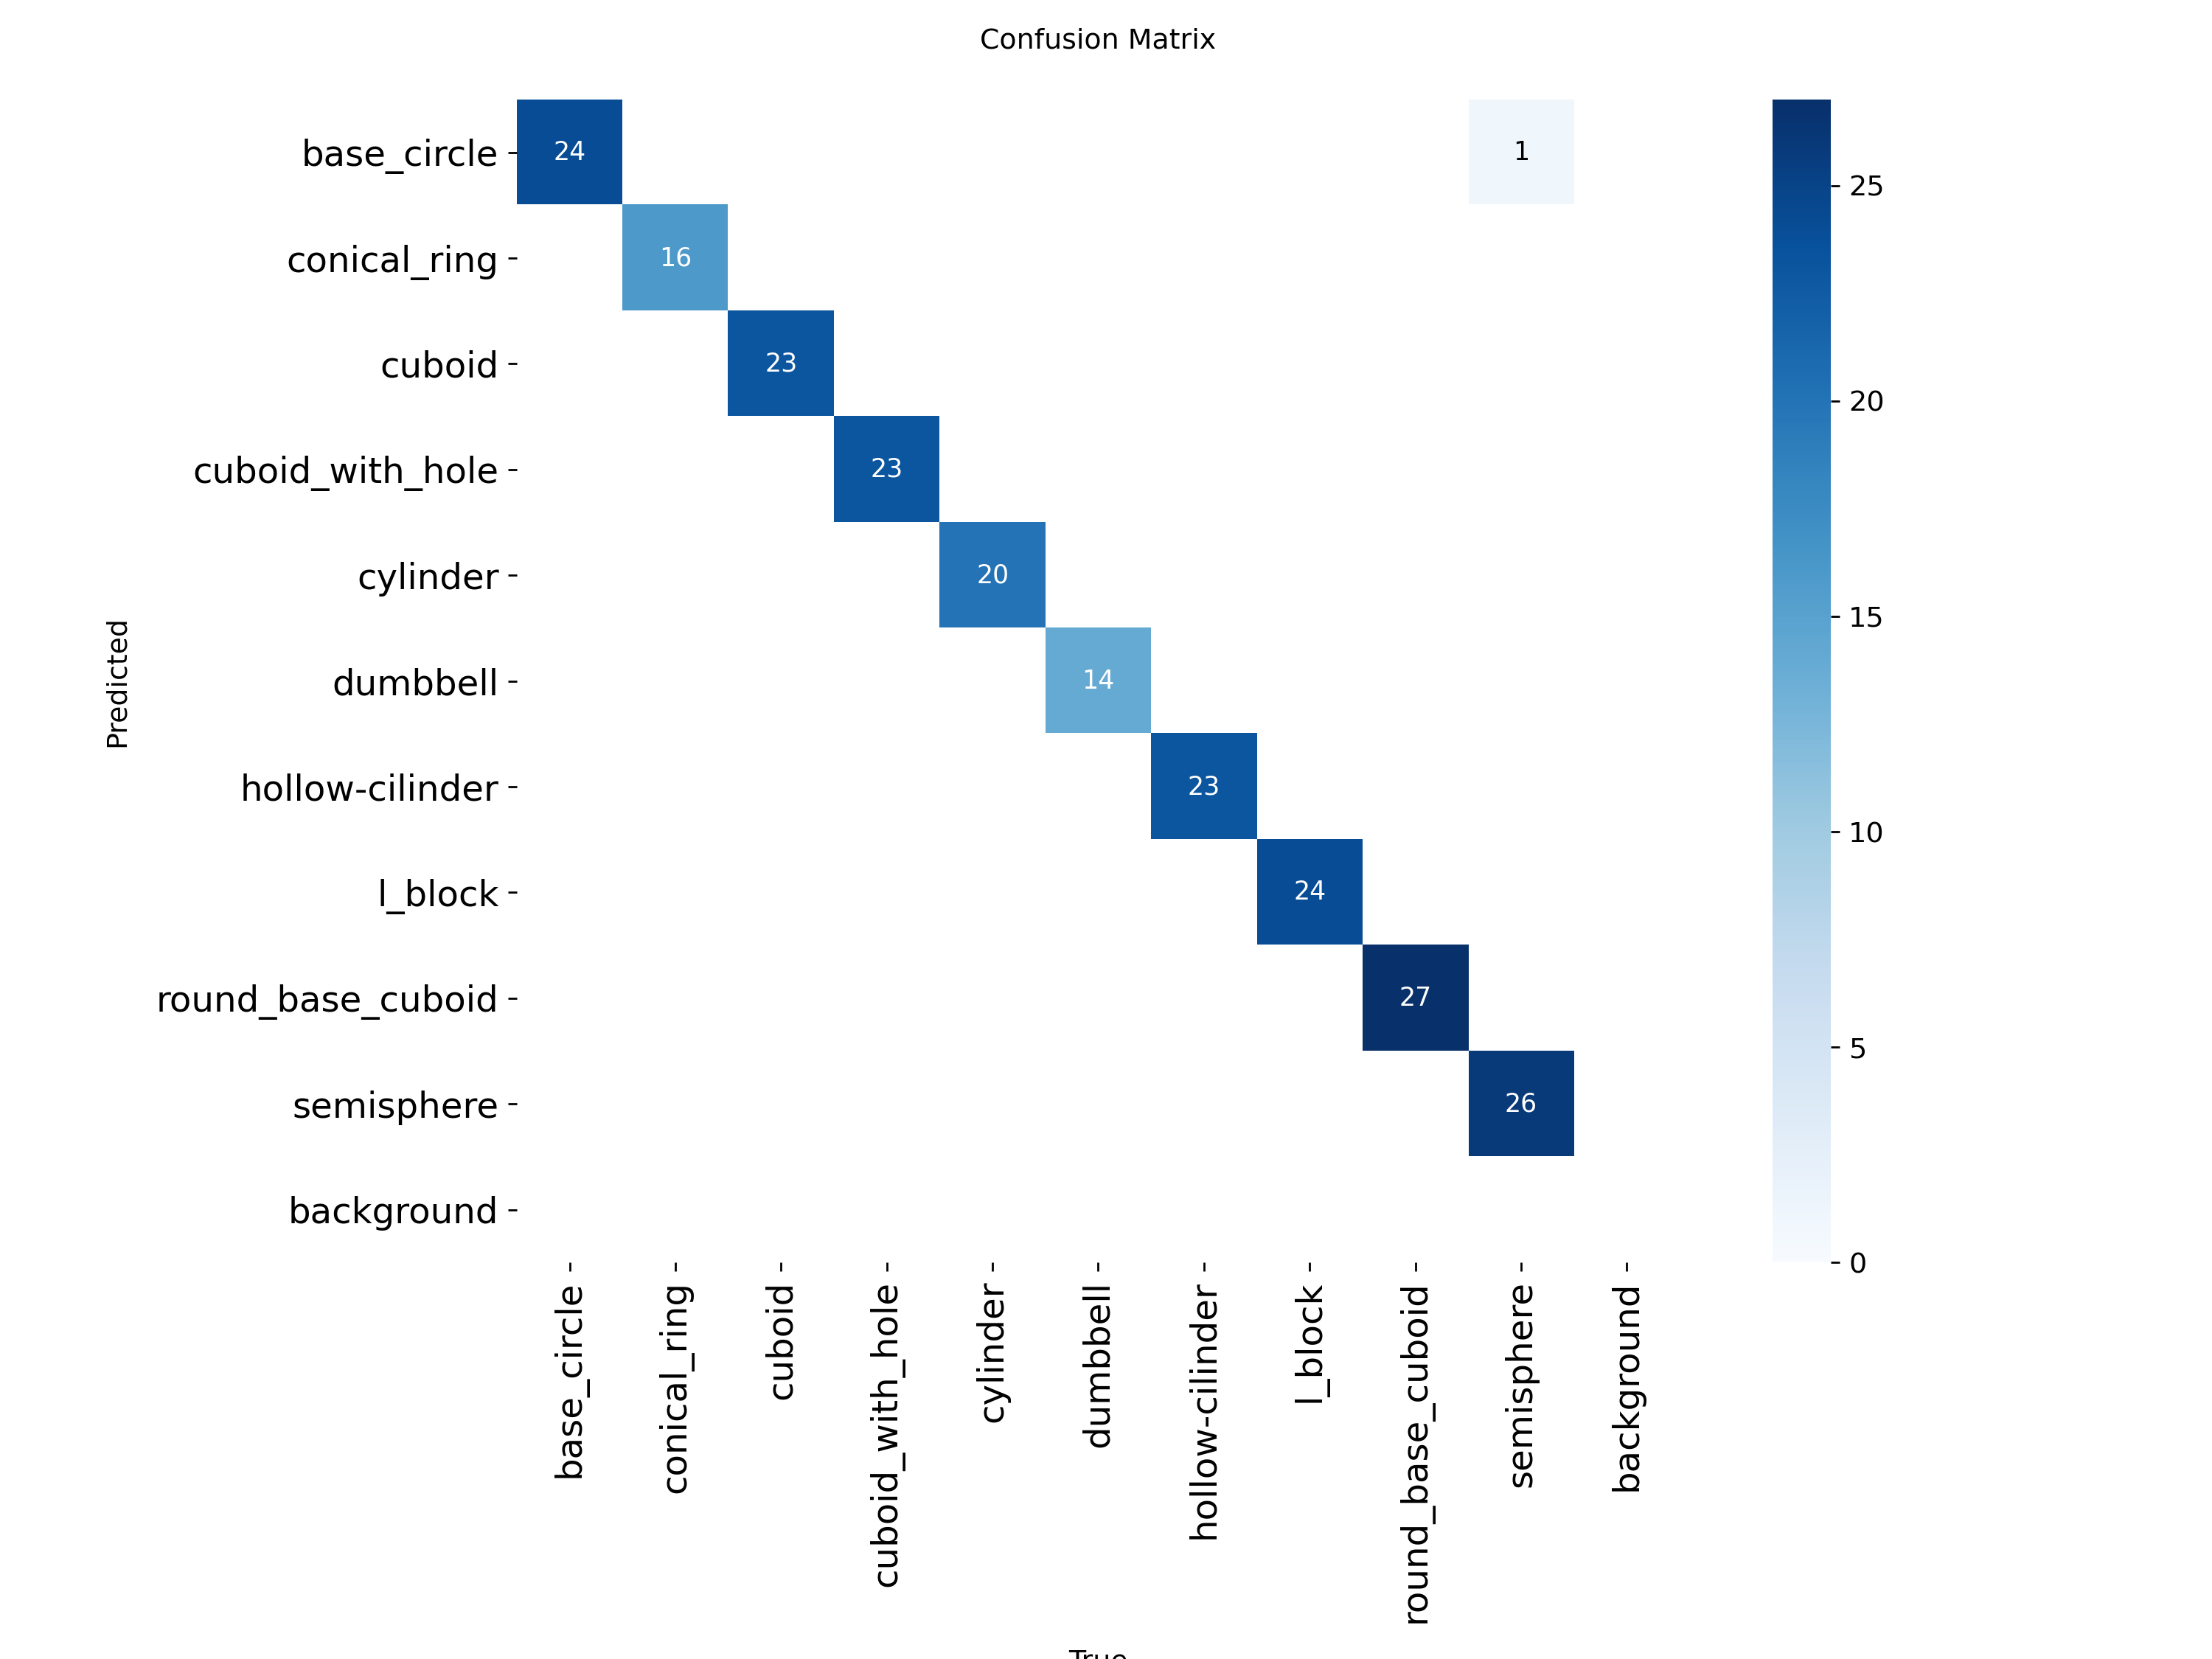

In [ ]:
# Apresentando a matriz de confusão do conjunto de teste
Image(filename=f'/content/runs/detect/val/confusion_matrix.png', width=800)

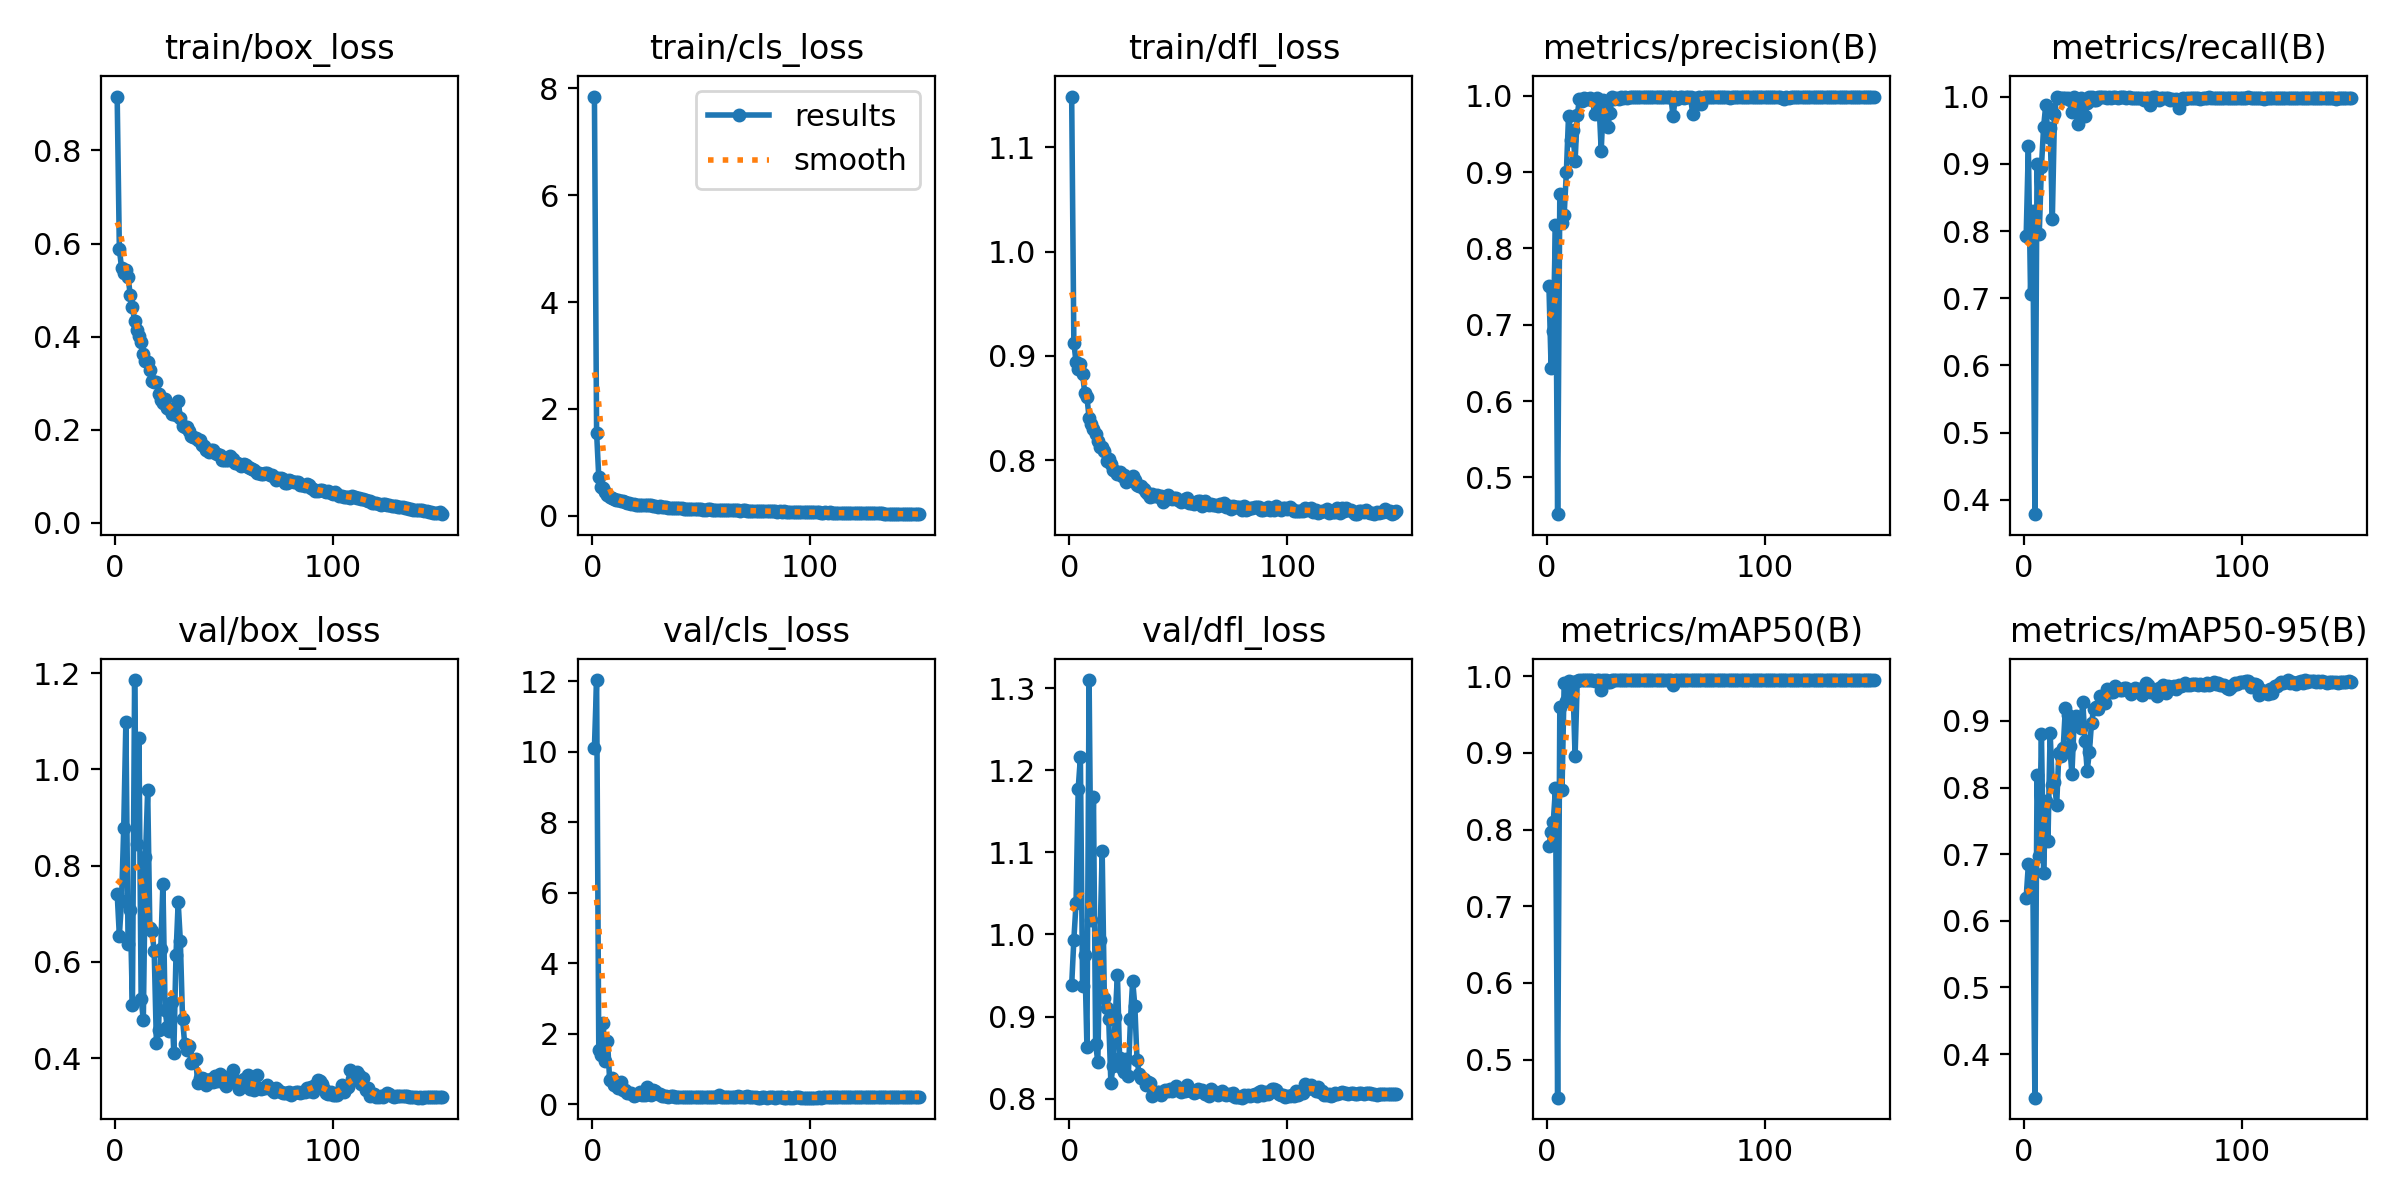

In [ ]:
# Apresentando métricas do treino e validação
Image(filename=f'/content/runs/detect/train3/results.png', width=800)